<a href="https://colab.research.google.com/github/ajai1996/python_practice/blob/main/Unsupervised_learning_casestudy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler,MinMaxScaler

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import dendrogram,linkage
from sklearn.cluster import AgglomerativeClustering

from sklearn.decomposition import PCA

#Load Data(Training Data)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

filepath='/content/drive/MyDrive/DSA ICT/Data/adult_dataset.csv'
df=pd.read_csv(filepath)
df.head()

Mounted at /content/drive


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40.0,NaN,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             46400 non-null  float64
 1   workclass       45480 non-null  object 
 2   fnlwgt          48842 non-null  int64  
 3   education       48842 non-null  object 
 4   education-num   48842 non-null  int64  
 5   marital-status  48842 non-null  object 
 6   occupation      45485 non-null  object 
 7   relationship    48842 non-null  object 
 8   race            48842 non-null  object 
 9   sex             48842 non-null  object 
 10  capital-gain    48842 non-null  int64  
 11  capital-loss    48842 non-null  int64  
 12  hours-per-week  46400 non-null  float64
 13  native-country  46137 non-null  object 
 14  income          48842 non-null  object 
dtypes: float64(2), int64(4), object(9)
memory usage: 5.6+ MB


#Data Cleaning

In [4]:
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
  print('Coloumn : ',col)
  print(df[col].value_counts(dropna=False))
print('Categorical columns:\n',cat_cols)

Coloumn :  workclass
workclass
Private             32220
Self-emp-not-inc     3649
NaN                  3362
Local-gov            2973
State-gov            1877
?                    1763
Self-emp-inc         1625
Federal-gov          1346
Without-pay            18
Never-worked            9
Name: count, dtype: int64
Coloumn :  education
education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           955
Prof-school       834
9th               756
12th              657
Doctorate         594
5th-6th           509
1st-4th           247
Preschool          83
Name: count, dtype: int64
Coloumn :  marital-status
marital-status
Married-civ-spouse       22379
Never-married            16117
Divorced                  6633
Separated                 1530
Widowed                   1518
Married-spouse-absent      628
Married-AF-spouse           37
Name: count, dty

In [5]:
df.drop(columns=['education'],inplace=True)

Handling Duplicates

In [6]:
df.duplicated().sum()

np.int64(16)

In [7]:
df.T.duplicated().sum()

np.int64(0)

In [8]:
df.drop_duplicates(inplace=True)

In [9]:
df.duplicated().sum()

np.int64(0)

Handling Missing Values

In [10]:
df.isnull().sum()

,0
age,2442
workclass,3362
fnlwgt,0
education-num,0
marital-status,0
occupation,3357
relationship,0
race,0
sex,0
capital-gain,0


In [11]:
df['native-country'] = df['native-country'].replace('?', np.nan)
df['workclass'] = df['workclass'].replace('?', np.nan)
df['occupation'] = df['occupation'].replace('?', np.nan)

<Axes: >

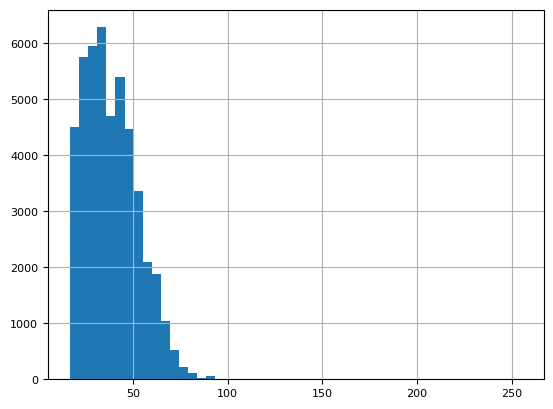

In [12]:
df['age'].hist(bins=50,xlabelsize=8,ylabelsize=8)

<Axes: >

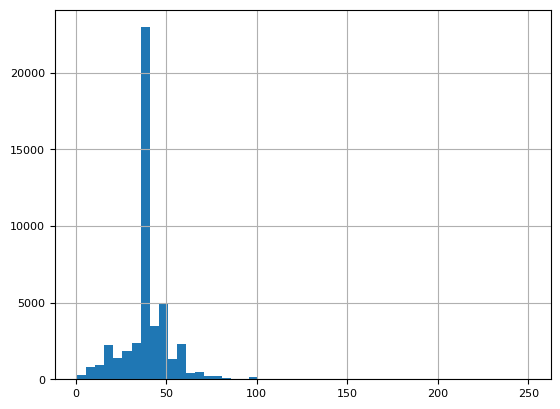

In [13]:
df['hours-per-week'].hist(bins=50,xlabelsize=8,ylabelsize=8)

In [14]:
df['age'] = df['age'].fillna(df['age'].median())
df['occupation'] = df['occupation'].fillna(df['occupation'].mode())
df['native-country'] = df['native-country'].fillna(df['native-country'].mode())
df['hours-per-week'] = df['hours-per-week'].fillna(df['hours-per-week'].mean())
df['workclass'] = df['workclass'].fillna(df['workclass'].mode())

Outliers Handling

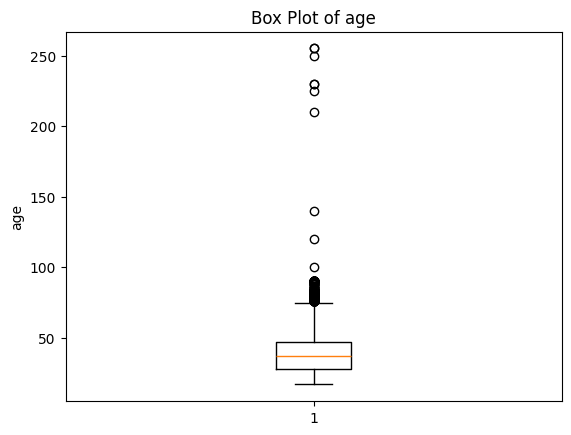

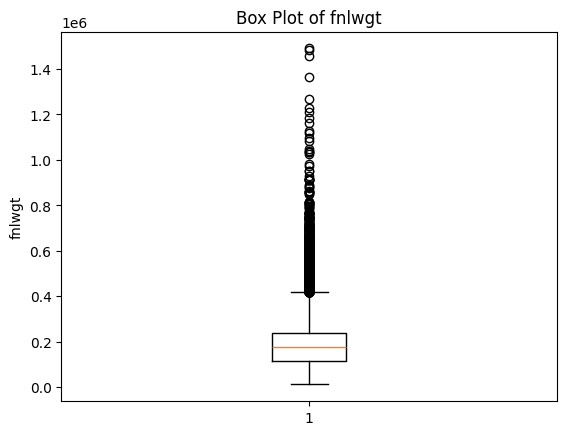

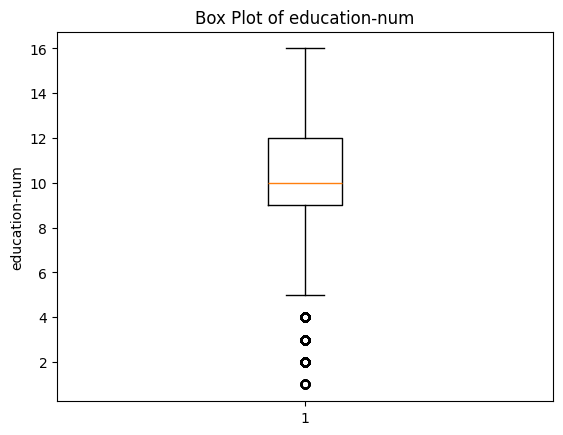

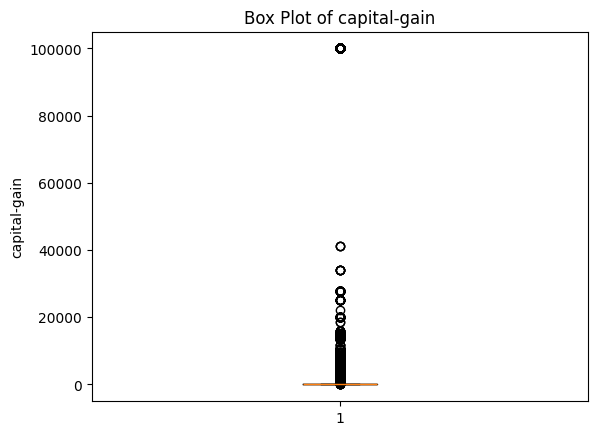

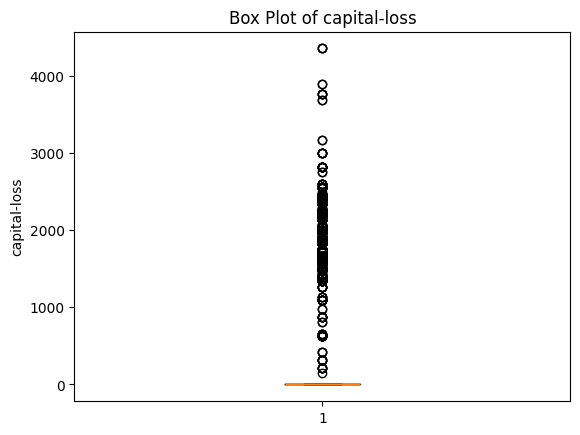

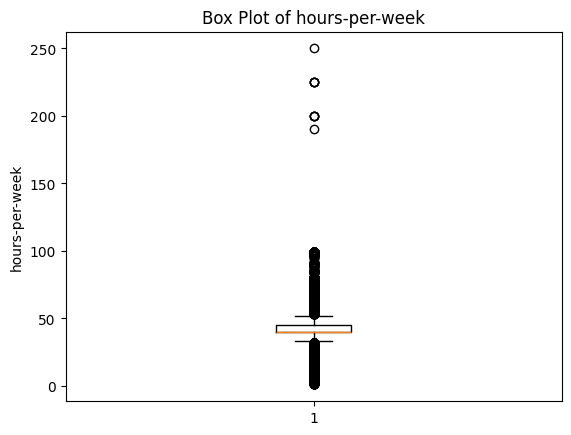

In [15]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in num_cols:
    plt.figure()
    plt.boxplot(df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
    plt.show()

Outlier Removal(IQR Method)

In [16]:
for col in num_cols:
  q1=np.percentile(df[col],25)
  q3=np.percentile(df[col],75)
  iqr=q3-q1
  print(col,q1,q3,iqr)

  up_val=q3+1.5*iqr
  low_val=q1-1.5*iqr
  print(up_val,low_val)

  df[col]=df[col].clip(lower=low_val,upper=up_val)


age 28.0 47.0 19.0
75.5 -0.5
fnlwgt 117555.0 237617.0 120062.0
417710.0 -62538.0
education-num 9.0 12.0 3.0
16.5 4.5
capital-gain 0.0 0.0 0.0
0.0 0.0
capital-loss 0.0 0.0 0.0
0.0 0.0
hours-per-week 40.0 45.0 5.0
52.5 32.5


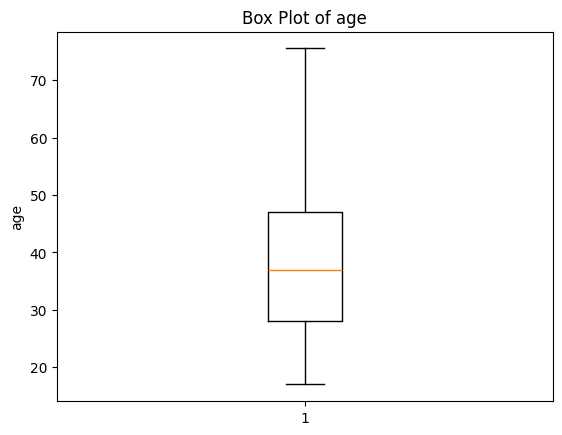

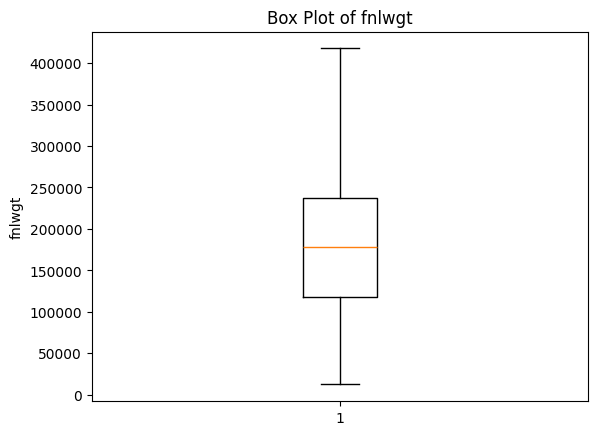

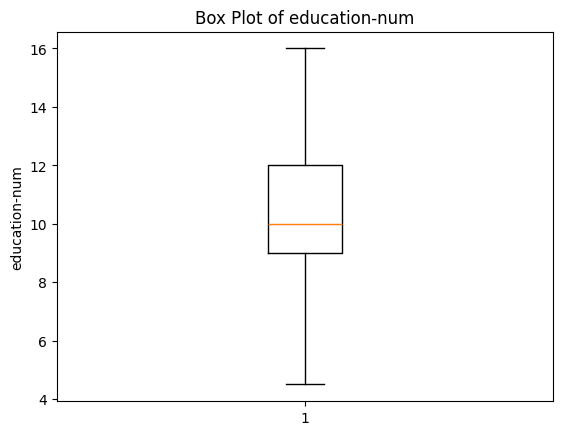

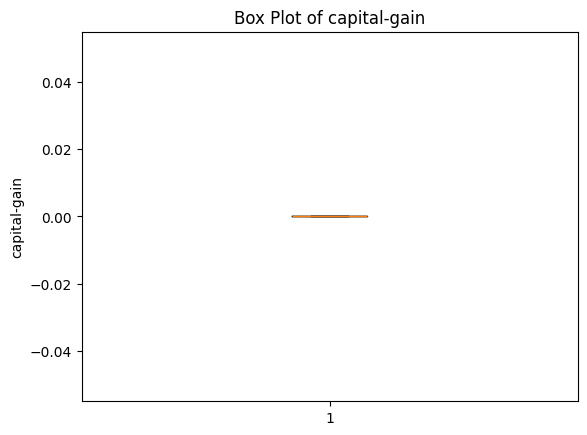

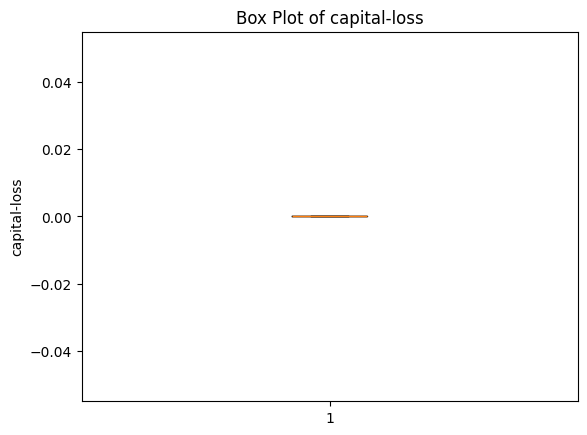

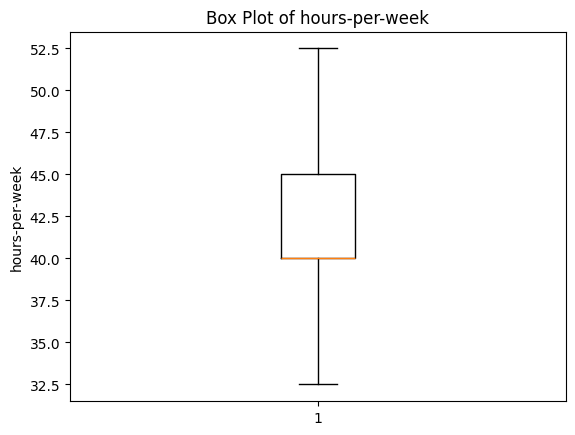

In [17]:
for col in num_cols:
    plt.figure()
    plt.boxplot(df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
    plt.show()

#Feature Engineering

In [18]:
df1=df.select_dtypes(include=['number'])
corr=df1.corr()
corr

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
age,1.000000,-0.076939,0.041684,NaN,NaN,0.090653
fnlwgt,-0.076939,1.000000,-0.034830,NaN,NaN,-0.018419
education-num,0.041684,-0.034830,1.000000,NaN,NaN,0.177159
capital-gain,NaN,NaN,NaN,NaN,NaN,NaN
capital-loss,NaN,NaN,NaN,NaN,NaN,NaN
hours-per-week,0.090653,-0.018419,0.177159,NaN,NaN,1.000000


<Axes: >

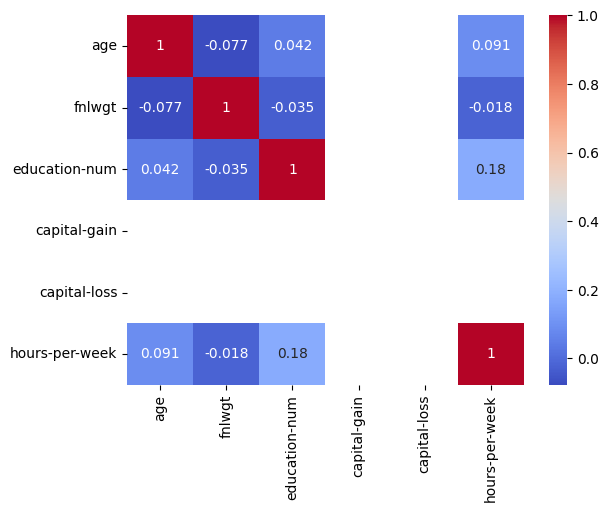

In [19]:
sns.heatmap(corr,annot=True,cmap='coolwarm')

In [20]:
df.drop(columns=['fnlwgt'],inplace=True)

#Encoding

In [21]:
df['income'] = df['income'].replace('<=50K.', '<=50K')
df['income'] = df['income'].replace('>50K.', '>50K')

In [22]:
df2=df.copy()

In [23]:
df2.drop(columns=['income'],inplace=True)

One Hot Encoding

In [24]:
cat_cols_df2 = df2.select_dtypes(include=['object']).columns
df2= pd.get_dummies(df2, columns=cat_cols_df2, drop_first=True,dtype=int)
df2.head()

,age,education-num,capital-gain,capital-loss,hours-per-week,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,39.0,13.0,0,0,40.0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,50.0,13.0,0,0,32.5,0,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
2,38.0,9.0,0,0,40.0,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
3,53.0,7.0,0,0,40.0,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
4,28.0,13.0,0,0,40.0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0


#Scaling

In [25]:
ss = StandardScaler()
df_scaled = ss.fit_transform(df2)

In [26]:
df_scaled = pd.DataFrame(df_scaled, columns=df2.columns)
df_scaled.head()

,age,education-num,capital-gain,capital-loss,hours-per-week,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,0.035123,1.171344,0.0,0.0,-0.191218,-0.254632,-0.013578,-1.391980,-0.185487,-0.284203,...,-0.036791,-0.059975,-0.020243,-0.046644,-0.035368,-0.024378,-0.022634,0.416437,-0.041265,-0.021709
1,0.864064,1.171344,0.0,0.0,-1.434968,-0.254632,-0.013578,-1.391980,-0.185487,3.518615,...,-0.036791,-0.059975,-0.020243,-0.046644,-0.035368,-0.024378,-0.022634,0.416437,-0.041265,-0.021709
2,-0.040236,-0.456772,0.0,0.0,-0.191218,-0.254632,-0.013578,0.718401,-0.185487,-0.284203,...,-0.036791,-0.059975,-0.020243,-0.046644,-0.035368,-0.024378,-0.022634,0.416437,-0.041265,-0.021709
3,1.090139,-1.270830,0.0,0.0,-0.191218,-0.254632,-0.013578,0.718401,-0.185487,-0.284203,...,-0.036791,-0.059975,-0.020243,-0.046644,-0.035368,-0.024378,-0.022634,0.416437,-0.041265,-0.021709
4,-0.793819,1.171344,0.0,0.0,-0.191218,-0.254632,-0.013578,0.718401,-0.185487,-0.284203,...,-0.036791,-0.059975,-0.020243,-0.046644,-0.035368,-0.024378,-0.022634,-2.401323,-0.041265,-0.021709


In [27]:
df_scaled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48826 entries, 0 to 48825
Data columns (total 81 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   age                                        48826 non-null  float64
 1   education-num                              48826 non-null  float64
 2   capital-gain                               48826 non-null  float64
 3   capital-loss                               48826 non-null  float64
 4   hours-per-week                             48826 non-null  float64
 5   workclass_Local-gov                        48826 non-null  float64
 6   workclass_Never-worked                     48826 non-null  float64
 7   workclass_Private                          48826 non-null  float64
 8   workclass_Self-emp-inc                     48826 non-null  float64
 9   workclass_Self-emp-not-inc                 48826 non-null  float64
 10  workclass_State-gov   

#PCA

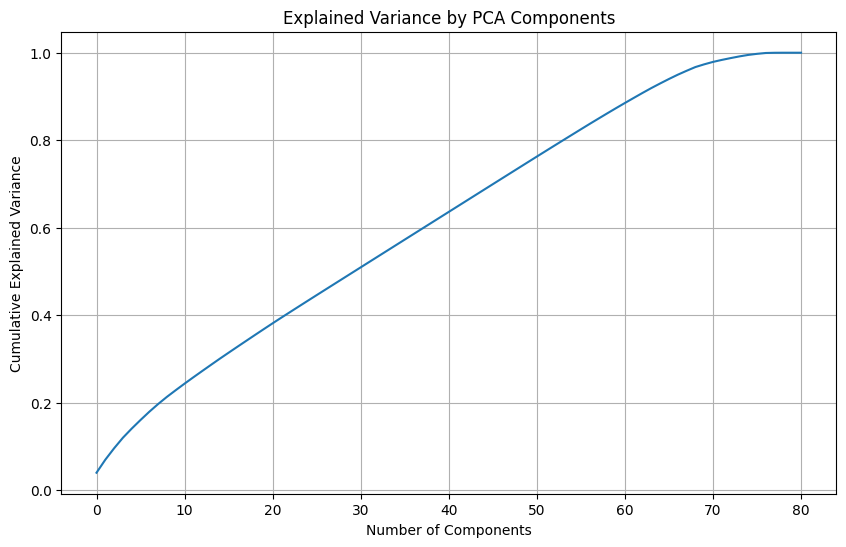

In [28]:
pca = PCA()
pca.fit(df_scaled)

plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by PCA Components')
plt.grid()
plt.show()

In [29]:
print(np.cumsum(pca.explained_variance_ratio_))

[0.03998681 0.06973305 0.09588088 0.11999334 0.14090245 0.16053129
 0.17942374 0.19704767 0.21345589 0.22869885 0.24361169 0.25814903
 0.27241926 0.28656479 0.30061986 0.31431557 0.32792581 0.34143054
 0.35490711 0.36828477 0.3815412  0.39461156 0.40750386 0.42035539
 0.43318584 0.44594922 0.45866336 0.47136401 0.48405959 0.49675296
 0.50944139 0.52212647 0.53480851 0.5474869  0.5601643  0.57284002
 0.58551273 0.59818528 0.61085583 0.62352596 0.6361942  0.64886128
 0.66152812 0.67419341 0.68684965 0.69950143 0.71214979 0.72478959
 0.73741845 0.75004347 0.76263306 0.77517675 0.78769482 0.80015177
 0.81257664 0.82498088 0.83730948 0.84944005 0.86149285 0.87340417
 0.88512759 0.89665891 0.90809885 0.9192168  0.92973951 0.9399691
 0.94973203 0.95867144 0.96722469 0.97344833 0.9789955  0.98355528
 0.98769901 0.99159651 0.99495947 0.99745475 0.99940163 0.99987639
 1.         1.         1.        ]


In [30]:
pca = PCA(n_components=0.95) # Retain 95% of the variance
df_pca = pca.fit_transform(df_scaled)

print(f"Number of components retained: {pca.n_components_}")
df_pca = pd.DataFrame(df_pca, columns=[f'PC_{i+1}' for i in range(pca.n_components_)])
df_pca.head()

Number of components retained: 68


,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6,PC_7,PC_8,PC_9,PC_10,...,PC_59,PC_60,PC_61,PC_62,PC_63,PC_64,PC_65,PC_66,PC_67,PC_68
0,-0.341387,0.867151,2.206154,1.517322,-0.230087,-1.295724,-0.859361,-0.696346,-0.679864,-0.211772,...,-0.650630,-0.297099,-0.094235,-0.120866,-0.132616,-0.315562,0.232872,-0.385542,0.048011,-1.460843
1,2.611846,0.110010,0.806919,0.261631,0.233375,-1.137794,0.124680,1.530578,1.202447,-0.308454,...,-0.713373,0.104343,-0.406904,0.210958,0.584733,-0.995579,-2.418543,-0.127885,-0.244377,0.867161
2,-0.573539,1.072940,-0.821282,-0.140496,-0.403880,0.373766,-1.227988,-0.554179,-1.074413,0.176415,...,-0.415165,-0.205557,1.212211,-0.290278,0.203835,0.101256,0.224981,-0.015322,1.094726,-0.351560
3,-0.247952,-1.682813,-1.361797,-1.642722,3.125706,0.700851,-1.035884,-0.663672,-0.193384,-0.045172,...,-0.254903,-0.240022,0.801294,0.155845,-0.729515,0.719965,-0.074627,-0.681650,0.269096,-0.080350
4,-0.070355,-3.822464,0.797583,-0.329622,-0.034283,1.114890,3.424411,-2.746720,2.851642,-1.013452,...,-1.289961,-1.852892,-1.611091,2.136215,-2.785181,0.092090,1.982490,-0.742733,-0.229788,0.679395


In [31]:
df_scaled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48826 entries, 0 to 48825
Data columns (total 81 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   age                                        48826 non-null  float64
 1   education-num                              48826 non-null  float64
 2   capital-gain                               48826 non-null  float64
 3   capital-loss                               48826 non-null  float64
 4   hours-per-week                             48826 non-null  float64
 5   workclass_Local-gov                        48826 non-null  float64
 6   workclass_Never-worked                     48826 non-null  float64
 7   workclass_Private                          48826 non-null  float64
 8   workclass_Self-emp-inc                     48826 non-null  float64
 9   workclass_Self-emp-not-inc                 48826 non-null  float64
 10  workclass_State-gov   

#Unsupervised Learning

K-means clustering

In [32]:
wcss=[]
sil=[]

for k in range(2,5):
  kmeans=KMeans(n_clusters=k,init='k-means++',max_iter=300,n_init=10,random_state=0)
  kmeans.fit(df_pca)
  wcss.append(kmeans.inertia_)

  labels=kmeans.predict(df_pca)
  sil_score=silhouette_score(df_pca,labels)
  print('Silhouette score for k = {} is {} and {}'.format(k,kmeans.inertia_,sil_score))

  sil.append(sil_score)


Silhouette score for k = 2 is 3572767.8530088784 and 0.07685740549092869
Silhouette score for k = 3 is 3487874.4870561045 and 0.0564910177816969
Silhouette score for k = 4 is 3438660.706650488 and 0.05804021412064232


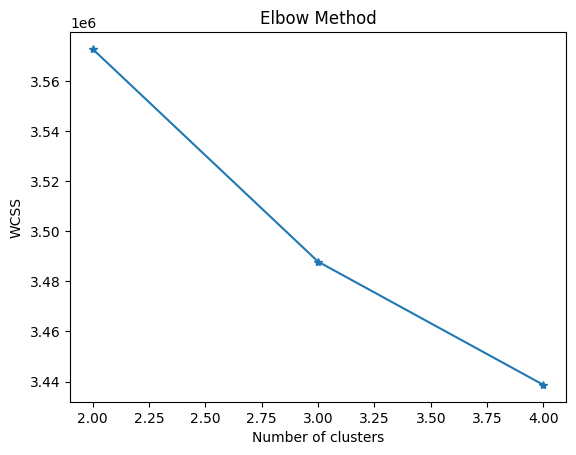

In [33]:
plt.plot(range(2, 5), wcss,marker='*')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

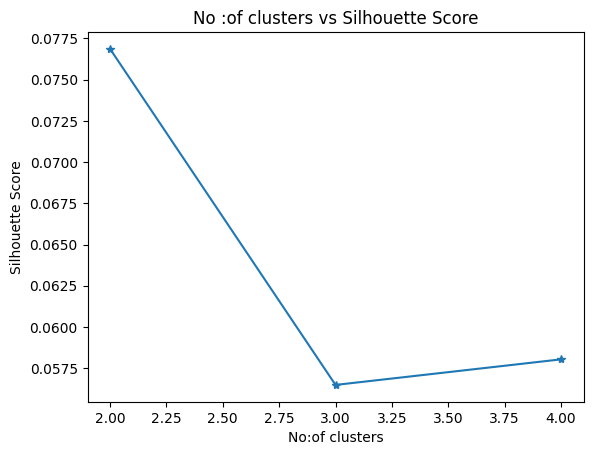

In [34]:
plt.plot(range(2,5),sil,marker='*')
plt.title('No :of clusters vs Silhouette Score')
plt.ylabel('Silhouette Score')
plt.xlabel('No:of clusters')
plt.show()

In [35]:
kmeans=KMeans(n_clusters=2,init='k-means++',random_state=0,max_iter=300,n_init=10) #using k=2
kmeans_labels=kmeans.fit_predict(df_pca)
df['kmeans_clusters']=kmeans_labels
df.head()

,age,workclass,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income,kmeans_clusters
0,39.0,State-gov,13.0,Never-married,Adm-clerical,Not-in-family,White,Male,0,0,40.0,United-States,<=50K,1
1,50.0,Self-emp-not-inc,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,32.5,United-States,<=50K,0
2,38.0,Private,9.0,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40.0,United-States,<=50K,1
3,53.0,Private,7.0,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40.0,United-States,<=50K,0
4,28.0,Private,13.0,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K,0


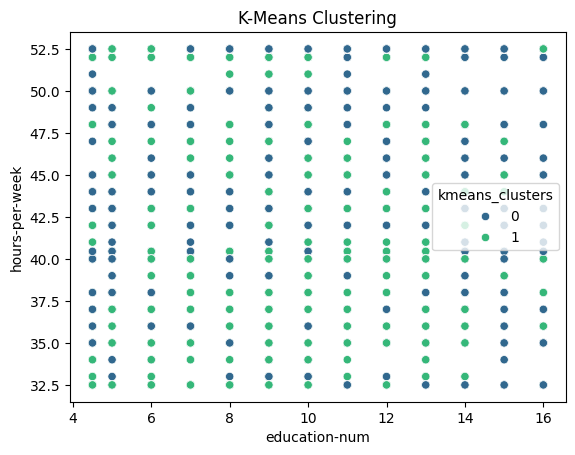

In [36]:
sns.scatterplot(x='education-num',y='hours-per-week',hue='kmeans_clusters',data=df,palette='viridis')
plt.title('K-Means Clustering')
plt.xlabel('education-num')
plt.ylabel('hours-per-week')
plt.show()

In [37]:
sample_size = 20000 #  adjust this number based on our memory and visualization needs
X = df_pca.sample(n=min(len(df_pca), sample_size), random_state=42).values

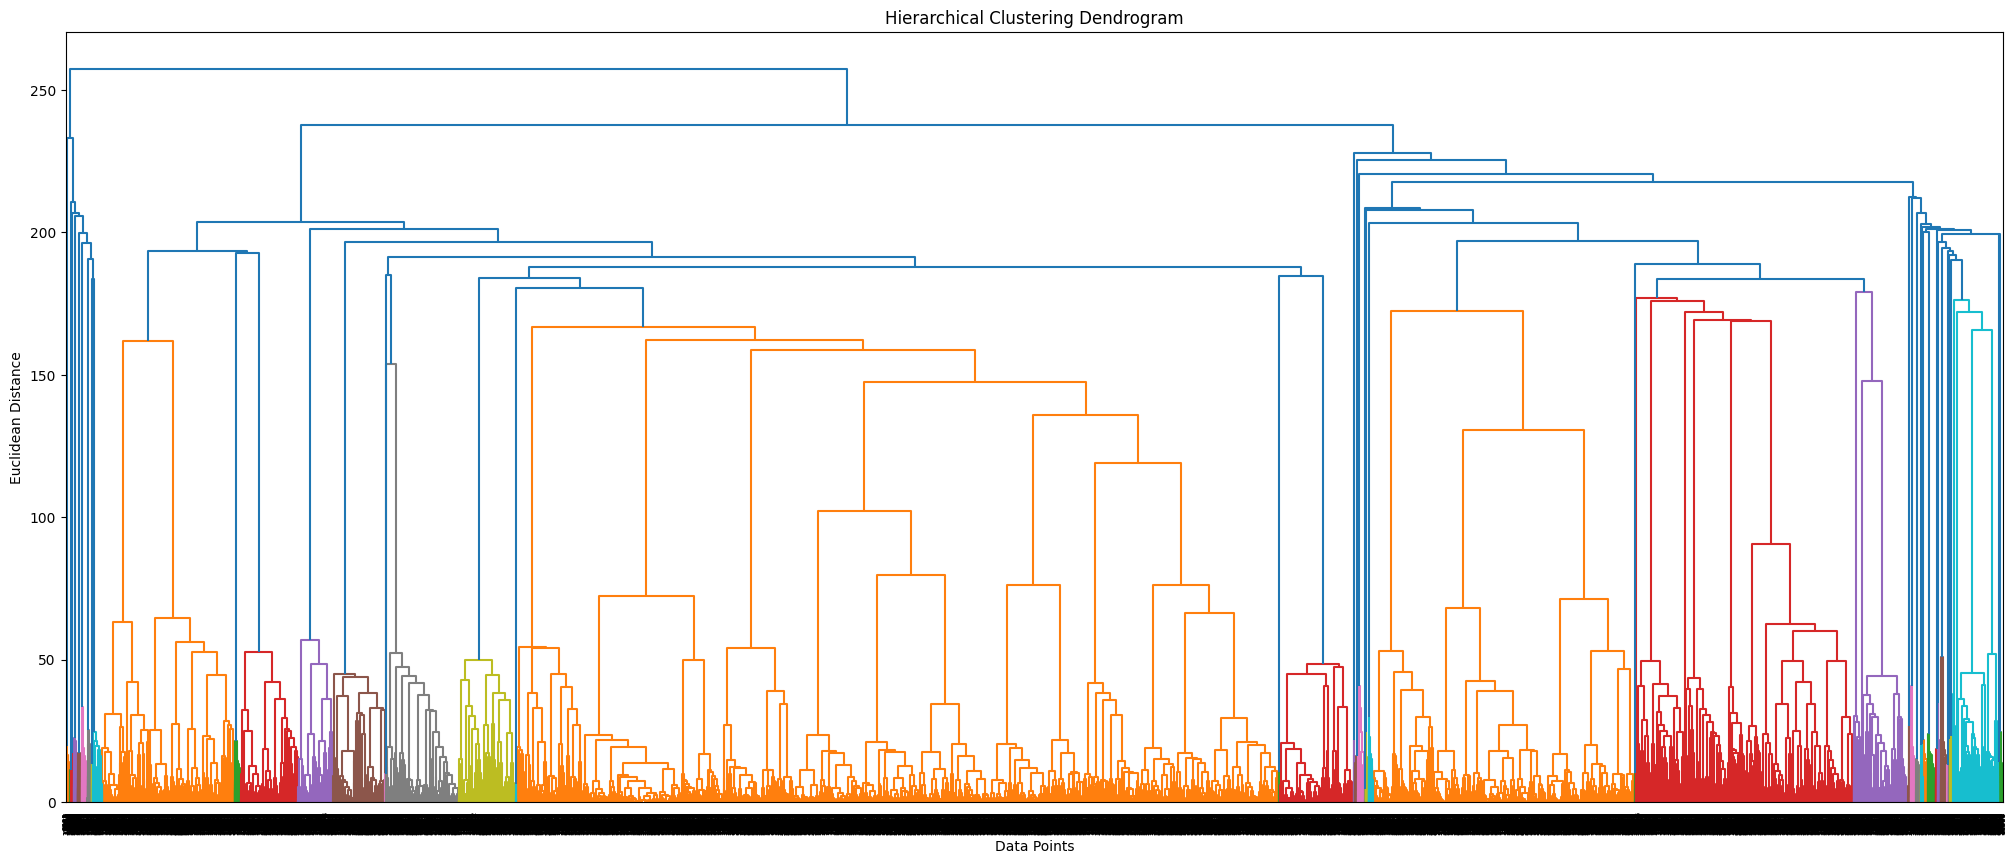

In [38]:
mergings = linkage(X, method='ward')
plt.figure(figsize=(25, 10))
dendrogram(mergings,leaf_rotation=90)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel('Data Points')
plt.ylabel('Euclidean Distance')
plt.show()


#Agglomerative Clustering

In [39]:
sil1=[]
for k1 in range(2,5):
  hc=AgglomerativeClustering(n_clusters=k1,linkage='ward')
  hc_labels=hc.fit_predict(X)
  sil_score1=silhouette_score(X,hc_labels)
  print('silhouette score for k={} is {}'.format(k1,sil_score1))
  sil1.append(sil_score1)

silhouette score for k=2 is 0.6074382341282443
silhouette score for k=3 is 0.13843906033178052
silhouette score for k=4 is 0.1408640523886005


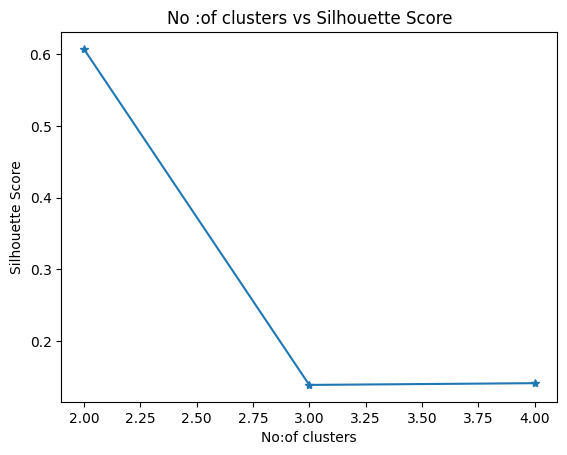

In [40]:
plt.plot(range(2,5),sil1,marker='*')
plt.title('No :of clusters vs Silhouette Score')
plt.ylabel('Silhouette Score')
plt.xlabel('No:of clusters')
plt.show()

In [41]:
X= pd.DataFrame(X, columns=df_pca.columns)
X.head()

,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6,PC_7,PC_8,PC_9,PC_10,...,PC_59,PC_60,PC_61,PC_62,PC_63,PC_64,PC_65,PC_66,PC_67,PC_68
0,0.347624,0.330170,-0.658787,-0.627554,0.269674,0.533924,1.173412,0.385354,-0.737196,-0.067525,...,-0.057102,1.284921,0.341740,-0.965114,-0.468220,1.574090,-1.031811,0.158046,0.073019,-0.232401
1,1.451347,0.472945,-1.030885,-0.109437,0.353818,0.804630,-0.237615,-0.184318,-0.153944,0.081035,...,-0.201933,0.120646,-0.186314,-0.394362,-0.182226,0.394228,0.248461,-0.058522,0.393074,-0.132762
2,1.812971,0.160073,1.082167,0.685023,0.760346,-0.584201,0.566836,-0.280675,0.349356,1.273798,...,-1.138805,-0.299456,-0.608571,-0.228102,0.013491,-0.719382,-0.577894,-0.227367,-0.784702,-1.637240
3,1.023373,-0.291667,-1.216766,0.801180,-0.752324,0.919200,0.424814,-0.147718,1.084563,0.153163,...,-0.546280,0.175502,-0.339693,-0.596666,-0.259183,-0.099215,-0.639230,-0.583286,-0.649145,-0.484594
4,3.078004,-0.025178,0.629842,0.497501,1.567701,-1.877415,-0.350141,-0.831043,0.186459,4.418482,...,0.773475,-0.019989,0.732235,-0.685269,0.033133,1.868024,2.857441,1.192092,1.909233,4.264580


In [42]:
hc=AgglomerativeClustering(n_clusters=2,linkage='ward') #using k=2
hc_labels=hc.fit_predict(X)
X['HC']=hc_labels


In [43]:
X['HC'].value_counts()


,count
HC,
0,19625
1,375


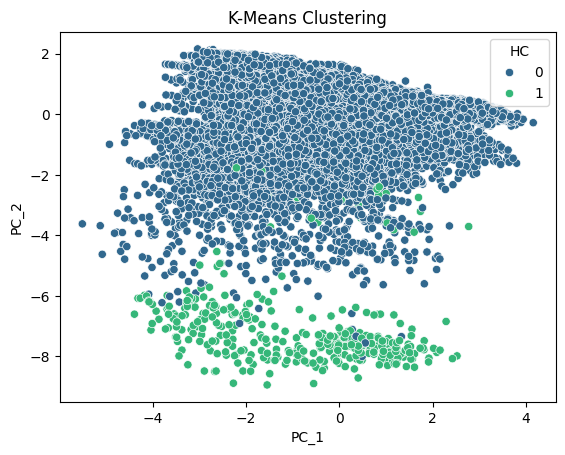

In [44]:
sns.scatterplot(x='PC_1',y='PC_2',hue='HC',data=X,palette='viridis')
plt.title('K-Means Clustering')
plt.xlabel('PC_1')
plt.ylabel('PC_2')
plt.show()

In [45]:
comparison_df=pd.crosstab(df['income'],df['kmeans_clusters'])
comparison_df

kmeans_clusters,0,1
income,,
<=50K,12880,24259
>50K,10222,1465


#Interpretation & Profiling


Analyze the demographic and work attributes of KMeans clusters 0 and 1 from the original DataFrame `df`, focusing on 'age', 'education-num', 'workclass', 'occupation', 'hours-per-week', and 'income'. Compare the characteristics of these clusters using `comparison_df` to provide insights into each group and propose targeted interventions such as upskilling programs, tax reform, and financial aid or inclusion efforts. Finally, summarize the findings and proposed interventions.

## Profile Cluster 0
Analyze the demographic and work attributes of Cluster 0 (from KMeans) by examining the mean/median of numerical features and the mode/value counts of categorical features in the original DataFrame, focusing on 'age', 'education-num', 'workclass', 'occupation', 'hours-per-week', and 'income'.


In [46]:
cluster_0_df = df[df['kmeans_clusters'] == 0]

print('--- Numerical Feature Analysis for Cluster 0 ---')
print('Age - Mean:', cluster_0_df['age'].mean(), 'Median:', cluster_0_df['age'].median())
print('Education-Num - Mean:', cluster_0_df['education-num'].mean(), 'Median:', cluster_0_df['education-num'].median())
print('Hours-per-week - Mean:', cluster_0_df['hours-per-week'].mean(), 'Median:', cluster_0_df['hours-per-week'].median())

print('\n--- Categorical Feature Analysis for Cluster 0 ---')
print('\nWorkclass Value Counts:')
print(cluster_0_df['workclass'].value_counts())
print('\nOccupation Value Counts:')
print(cluster_0_df['occupation'].value_counts())
print('\nIncome Value Counts:')
print(cluster_0_df['income'].value_counts())

--- Numerical Feature Analysis for Cluster 0 ---
Age - Mean: 43.27707557787205 Median: 42.0
Education-Num - Mean: 10.379166305947537 Median: 10.0
Hours-per-week - Mean: 42.84199952736711 Median: 40.0

--- Categorical Feature Analysis for Cluster 0 ---

Workclass Value Counts:
workclass
Private             13966
Self-emp-not-inc     2673
Local-gov            1503
Self-emp-inc         1327
State-gov             876
Federal-gov           706
Without-pay            11
Never-worked            1
Name: count, dtype: int64

Occupation Value Counts:
occupation
Craft-repair         3783
Exec-managerial      3620
Prof-specialty       3128
Sales                2434
Transport-moving     1503
Adm-clerical         1425
Machine-op-inspct    1398
Other-service        1015
Farming-fishing       870
Handlers-cleaners     700
Tech-support          590
Protective-serv       582
Priv-house-serv        23
Armed-Forces            7
Name: count, dtype: int64

Income Value Counts:
income
<=50K    12880
>50K    

#Profile cluster 1
Analyze the demographic and work attributes of Cluster 1 (from KMeans) by examining the mean/median of numerical features and the mode/value counts of categorical features in the original DataFrame, focusing on 'age', 'education-num', 'workclass', 'occupation', 'hours-per-week', and 'income'.



In [47]:
cluster_1_df = df[df['kmeans_clusters'] == 1]

print('--- Numerical Feature Analysis for Cluster 1 ---')
print('Age - Mean:', cluster_1_df['age'].mean(), 'Median:', cluster_1_df['age'].median())
print('Education-Num - Mean:', cluster_1_df['education-num'].mean(), 'Median:', cluster_1_df['education-num'].median())
print('Hours-per-week - Mean:', cluster_1_df['hours-per-week'].mean(), 'Median:', cluster_1_df['hours-per-week'].median())

print('\n--- Categorical Feature Analysis for Cluster 1 ---')
print('\nWorkclass Value Counts:')
print(cluster_1_df['workclass'].value_counts())
print('\nOccupation Value Counts:')
print(cluster_1_df['occupation'].value_counts())
print('\nIncome Value Counts:')
print(cluster_1_df['income'].value_counts())

--- Numerical Feature Analysis for Cluster 1 ---
Age - Mean: 34.274238065619656 Median: 32.0
Education-Num - Mean: 9.891443787902348 Median: 10.0
Hours-per-week - Mean: 39.63629546441304 Median: 40.0

--- Categorical Feature Analysis for Cluster 1 ---

Workclass Value Counts:
workclass
Private             18239
Local-gov            1470
State-gov            1001
Self-emp-not-inc      976
Federal-gov           640
Self-emp-inc          297
Never-worked            8
Without-pay             7
Name: count, dtype: int64

Occupation Value Counts:
occupation
Adm-clerical         3903
Other-service        3639
Sales                2797
Prof-specialty       2723
Exec-managerial      2150
Craft-repair         2007
Machine-op-inspct    1474
Handlers-cleaners    1276
Tech-support          792
Transport-moving      735
Farming-fishing       558
Protective-serv       361
Priv-house-serv       210
Armed-Forces            8
Name: count, dtype: int64

Income Value Counts:
income
<=50K    24259
>50K    

Refer the `comparison_df` to highlight the income distribution across these two KMeans clusters, which is crucial for understanding their economic profiles and later proposing targeted interventions.



In [48]:
print('--- Income Distribution Across KMeans Clusters ---')
print(comparison_df)

--- Income Distribution Across KMeans Clusters ---
kmeans_clusters      0      1
income                       
<=50K            12880  24259
>50K             10222   1465


##Cluster Analysis and Proposed Interventions

### Cluster 0 Analysis:
**Demographics & Work Attributes:**
- **Age:** Mean age of 43.3 years, median age of 42.0 years. This cluster represents an older, more established workforce.
- **Education-Num:** Mean of 10.4, median of 10.0. This indicates a slightly higher education level compared to Cluster 1.
- **Hours-per-week:** Mean of 42.8 hours, median of 40.0 hours. Members work slightly more hours on average.
- **Workclass:** Predominantly `Private` sector (13,966), followed by `Self-emp-not-inc` (2,673) and `Local-gov` (1,503). This suggests a diverse mix of employment statuses, with a notable presence of self-employed individuals.
- **Occupation:** Key occupations include `Craft-repair` (3,783), `Exec-managerial` (3,620), and `Prof-specialty` (3,128). This indicates a cluster with skilled trades, management, and professional roles.
- **Income:** This cluster shows a higher proportion of individuals earning `>50K` (10,222) compared to `<=50K` (12,880). This cluster includes a significant portion of higher-income earners.

**Key Characteristics of Cluster 0:** This cluster is generally older, more educated, works slightly longer hours, and has a higher representation in skilled, professional, and managerial occupations. A substantial portion of this group earns above 50K annually.

**Proposed Interventions for Cluster 0:**
- **Tax Reform:** Given the higher income levels, policies regarding progressive taxation could be explored to ensure fair contributions to public services.
- **Retirement Planning & Investment Education:** Provide resources and incentives for retirement savings and investment strategies tailored to this age group, considering their potentially higher disposable income.
- **Advanced Professional Development:** Offer specialized training and certifications to help individuals in `Prof-specialty` and `Exec-managerial` roles stay competitive and advance further.

### Cluster 1 Analysis:
**Demographics & Work Attributes:**
- **Age:** Mean age of 34.3 years, median age of 32.0 years. This cluster represents a younger workforce.
- **Education-Num:** Mean of 9.9, median of 10.0. Education levels are slightly lower or similar to Cluster 0, primarily around high school graduate or some college.
- **Hours-per-week:** Mean of 39.6 hours, median of 40.0 hours. Members typically work standard full-time hours.
- **Workclass:** Overwhelmingly `Private` sector (18,239), followed by `Local-gov` (1,470) and `State-gov` (1,001). This indicates a strong reliance on private sector employment.
- **Occupation:** Dominant occupations include `Adm-clerical` (3,903), `Other-service` (3,639), and `Sales` (2,797). This suggests a cluster primarily engaged in administrative, service, and sales roles.
- **Income:** A significantly larger proportion of individuals in this cluster earn `<=50K` (24,259) compared to `>50K` (1,465). This cluster is largely composed of lower-income earners.

**Key Characteristics of Cluster 1:** This cluster is generally younger, works standard hours, and is heavily concentrated in entry-level or less specialized private sector roles. The vast majority of this group earns below 50K annually.

**Proposed Interventions for Cluster 1:**
- **Upskilling Programs:** Develop and promote vocational training and certification programs for in-demand skills to help individuals transition from `Adm-clerical` or `Other-service` roles to higher-paying occupations. Subsidize or make these programs easily accessible.
- **Financial Aid & Inclusion:** Implement programs to provide financial literacy education, access to affordable credit, and support for starting small businesses, addressing the needs of lower-income individuals.
- **Career Counseling & Job Placement:** Offer targeted career counseling and job placement services to guide individuals towards career paths with better growth potential and earning capacity.
- **Minimum Wage Review/Increase:** Advocacy for policies that ensure a living wage, potentially through minimum wage adjustments, to improve the economic stability of this group.


### Data Analysis Key Findings
*   **Cluster 0 - Established Workforce:**
    *   **Demographics:** This cluster represents an older workforce with a mean age of 43.3 years (median 42.0 years) and a higher education level, indicated by a mean education-num of 10.4 (median 10.0).
    *   **Work Attributes:** Members work slightly longer hours on average, with a mean of 42.8 hours per week (median 40.0 hours). They are predominantly in the `Private` sector (13,966 individuals), with significant representation in `Self-emp-not-inc` (2,673) and `Local-gov` (1,503). Key occupations include `Craft-repair` (3,783), `Exec-managerial` (3,620), and `Prof-specialty` (3,128).
    *   **Income:** A substantial portion (10,222) earns >\$50K, although 12,880 individuals still earn <\$50K.
*   **Cluster 1 - Younger, Lower-Income Workforce:**
    *   **Demographics:** This cluster is characterized by a younger workforce with a mean age of 34.3 years (median 32.0 years) and slightly lower or similar education levels compared to Cluster 0 (mean education-num of 9.9, median 10.0).
    *   **Work Attributes:** Members typically work standard full-time hours, with a mean of 39.6 hours per week (median 40.0 hours). They are overwhelmingly employed in the `Private` sector (18,239 individuals). Dominant occupations include `Adm-clerical` (3,903), `Other-service` (3,639), and `Sales` (2,797).
    *   **Income:** A significantly larger proportion (24,259) earns <\$50K, with only 1,465 individuals earning >\$50K.

### Insights or Next Steps
*   **Targeted Support for Cluster 1:** Implement upskilling and vocational training programs for Cluster 1 to facilitate their transition from administrative or service roles to higher-paying occupations, coupled with financial aid and literacy programs to improve their economic stability.
*   **Strategic Policies for Cluster 0:** Explore progressive tax reforms and provide resources for retirement planning and advanced professional development for Cluster 0, leveraging their higher income and established career paths to ensure fair contributions and continued growth.
